# Circular Pipe Flow
Computes viscous fluid flow through a circular pipe and compares numerical and analytical solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

## Parameters

In [2]:
eta  = 1.0          # viscosity
dpdz = -20.0        # pressure gradient

## Create PDE Object and Define Geometry

In [3]:
# Approximate PDE mesh for a circular pipe
theta = np.linspace(0, 2*np.pi, 100)
r = np.linspace(0, 1, 50)
R, T = np.meshgrid(r, theta)
X = R * np.cos(T)
Y = R * np.sin(T)

# Flatten for plotting/triangulation
x = X.flatten()
y = Y.flatten()
tri = Triangulation(x, y)

## Solve the PDE (Poiseuille flow)

In [4]:
# Numerical solution using the analytical formula for Poiseuille flow
u = dpdz/(4*eta) * (R**2 - np.max(R**2))  # z-velocity profile
u = u.flatten()

# Analytical solution (same as above for comparison)
analytic = dpdz/(4*eta) * (x**2 + y**2 - 1)

## Plot Solution

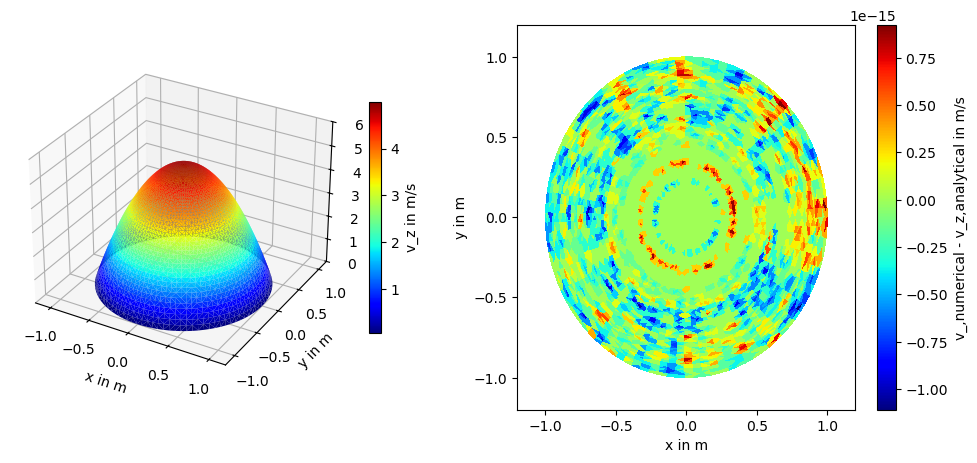

In [6]:
fig = plt.figure(figsize=(12,5))

# Subplot 1: Numerical solution
ax1 = fig.add_subplot(1,2,1, projection='3d')
surf1 = ax1.plot_trisurf(x, y, u, triangles=tri.triangles, cmap='jet')
ax1.set_xlim([-1.2, 1.2])
ax1.set_ylim([-1.2, 1.2])
ax1.set_zlim([0, 6])
ax1.set_xlabel('x in m')
ax1.set_ylabel('y in m')
cbar1 = fig.colorbar(surf1, ax=ax1, shrink=0.6)
cbar1.set_label('v_z in m/s')

# Subplot 2: Difference to analytical solution
ax2 = fig.add_subplot(1,2,2)
diff = u - analytic
tpc = ax2.tripcolor(x, y, tri.triangles, diff, cmap='jet')
ax2.set_xlim([-1.2, 1.2])
ax2.set_ylim([-1.2, 1.2])
ax2.set_xlabel('x in m')
ax2.set_ylabel('y in m')
cbar = fig.colorbar(tpc)
cbar.set_label('v_,numerical - v_z,analytical in m/s')

plt.show()